<a href="https://colab.research.google.com/github/cibele-vieira/timeseries/blob/main/Timeseries_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Introdução e Objetivo do Projeto

Objective & Dataset Overview

The objective of this project is to forecast future product demand (Units Sold) over time for a specific store and product using historical sales data.
The dataset represents daily retail operations across multiple stores and products, including sales, pricing, promotions, weather conditions, competitor pricing, and seasonality.
Each record corresponds to the number of units sold on a given date for a specific product and store.
This data allows the evaluation of different forecasting models and their ability to adapt to changes in demand patterns over time.

1. Importações e Carregamento do Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anirudhchauhan/retail-store-inventory-forecasting-dataset")

print("Path to dataset files:", path)
import os

path = "/root/.cache/kagglehub/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/versions/1"
os.listdir(path)

100%|██████████| 1.51M/1.51M [00:00<00:00, 58.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/versions/1


['retail_store_inventory.csv']

2.EDA

In [ ]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/versions/1"
df = pd.read_csv(f"{path}/retail_store_inventory.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
df.shape
df.duplicated().sum()
df.isna().sum()


,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['Date'].sort_values().diff().value_counts().head() #a granularidade temporal é diária/ Dataset é multi-series/dataset sintético

,count
Date,
0 days,72369
1 days,730


In [ ]:
df['Category'].nunique(), df['Category'].unique() #['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing']

(5,
 array(['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing'],
       dtype=object))

In [ ]:
df.groupby(['Region','Category']).size()#nenhuma categoria existe só em uma região,➡ nenhuma região domina uma categoria,➡ não tem viés estrutural de disponibilidade

Region  Category   
East    Clothing       3753
        Electronics    3705
        Furniture      3607
        Groceries      3684
        Toys           3600
North   Clothing       3528
        Electronics    3589
        Furniture      3720
        Groceries      3652
        Toys           3739
South   Clothing       3651
        Electronics    3606
        Furniture      3684
        Groceries      3704
        Toys           3652
West    Clothing       3694
        Electronics    3621
        Furniture      3688
        Groceries      3571
        Toys           3652
dtype: int64

In [ ]:
df[['Units Sold','Demand Forecast']].corr() # Data Leakege identificado

,Units Sold,Demand Forecast
Units Sold,1.000000,0.996853
Demand Forecast,0.996853,1.000000


In [ ]:
df['Date'].min(), df['Date'].max() #2 anos completos de histórico (2022 + 2023)

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [ ]:
df['Store ID'].nunique(), df['Product ID'].nunique() #100 séries temporais no total(se cada store tem os 20 produtos)

(5, 20)

In [ ]:
df['Units Sold'].describe() #Target tem variância alta Tem assimetria (média > mediana),Se a assimetria fosse muito grande, poderíamos aplicar log-transform para estabilizar a variância

,Units Sold
count,73100.000000
mean,136.464870
std,108.919406
min,0.000000
25%,49.000000
50%,107.000000
75%,203.000000
max,499.000000


In [ ]:
df = df.copy()
df['series_id'] = df['Store ID'] + '_' + df['Product ID']

In [ ]:
df['Units Sold'].eq(0).sum()
df['Units Sold'].eq(0).mean()

np.float64(0.004924760601915185)

In [ ]:
df['Units Sold'].eq(0).groupby(df['series_id']).mean() #As vendas zero sao raras (0,1% 0,7% por série), indicando demanda continua e ausencia de comportamento intermitente ou sinais de ruptura de estoque.

,Units Sold
series_id,
S001_P0001,0.005472
S001_P0002,0.006840
S001_P0003,0.004104
S001_P0004,0.005472
S001_P0005,0.001368
...,...
S005_P0016,0.005472
S005_P0017,0.002736
S005_P0018,0.006840


In [ ]:
df['Store ID'].nunique()
df['Product ID'].nunique()

20

In [ ]:
df[['Price','Competitor Pricing']].describe() #alta correlação

,Price,Competitor Pricing
count,73100.000000,73100.000000
mean,55.135108,55.146077
std,26.021945,26.191408
min,10.000000,5.030000
25%,32.650000,32.680000
50%,55.050000,55.010000
75%,77.860000,77.820000
max,100.000000,104.940000


In [ ]:
df['Holiday/Promotion'].mean() #49,7% de todos os dias no dataset são dias com promoção ou feriado.

np.float64(0.49730506155950754)

In [ ]:
df['Weather Condition'].value_counts() #Distribuição perfeitamente balanceada

,count
Weather Condition,
Sunny,18290
Rainy,18278
Snowy,18272
Cloudy,18260


Resultado do EDA: O dataset possui 2 anos de histórico diário, com 5 lojas e 20 produtos (100 séries), sem nulos nem duplicados.
As variáveis de negócio (Category, Region, Price, Promo, Seasonality e Weather) indicam comportamento de demanda com sazonalidade e efeitos promocionais.
Units Sold apresenta alta variância e potencial influência de preço, promoções e categorias.
Demand Forecast mostrou correlação quase perfeita com o target e foi identificado como data leakage, devendo ser removido da modelagem.As vendas zero são raras (~0,1%–0,7% por série), indicando demanda contínua e ausência de comportamento intermitente ou sinais de ruptura de estoque.

3.ETL / Data Preparation

In [ ]:
df = df.copy()#copiar o dataset para salvar o original de alterações feita no ETL

In [ ]:
df = df.sort_values(by=['Store ID','Product ID','Date']) # organiza o dataset no formato de séries temporais (forecasting exige ordem)

In [ ]:
df = df.drop(columns=['Demand Forecast']) #possivel data leakege

In [ ]:
df['series_id'] = df['Store ID'] + '_' + df['Product ID']   # identifica cada série temporal (loja×produto)

In [ ]:
target = 'Units Sold'

In [ ]:
features = [
    'Date', 'series_id', 'Units Sold', 'Inventory Level', 'Units Ordered',
    'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
    'Competitor Pricing', 'Seasonality', 'Category', 'Region'
]

EDA 2

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Weekday'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()

In [ ]:
df['Store'] = df['series_id'].str.split('_').str[0]
loja = 'S001'
df_loja = df[df['Store'] == loja][['Category','Month','Weekday','Units Sold']]
weekly_cat = df_loja.groupby(['Category','Weekday'])['Units Sold'].mean().reset_index()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_cat['Weekday'] = pd.Categorical(weekly_cat['Weekday'], categories=order, ordered=True)
weekly_cat = weekly_cat.sort_values('Weekday')



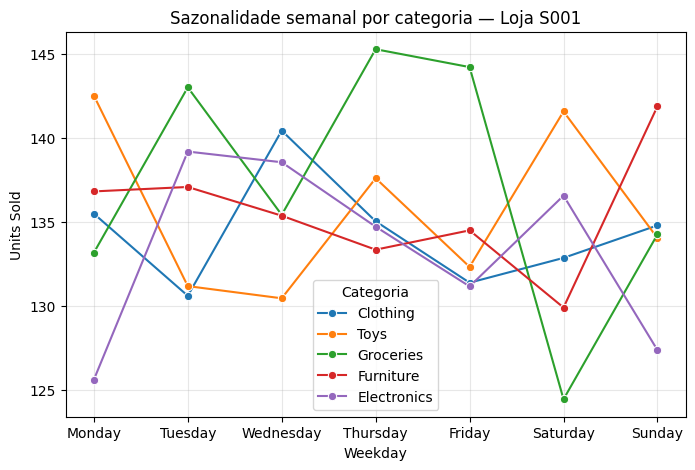

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.lineplot(data=weekly_cat, x='Weekday', y='Units Sold', hue='Category', marker='o')
plt.title(f"Sazonalidade semanal por categoria — Loja {loja}")
plt.legend(title='Categoria')
plt.grid(True, alpha=0.3)
plt.show()


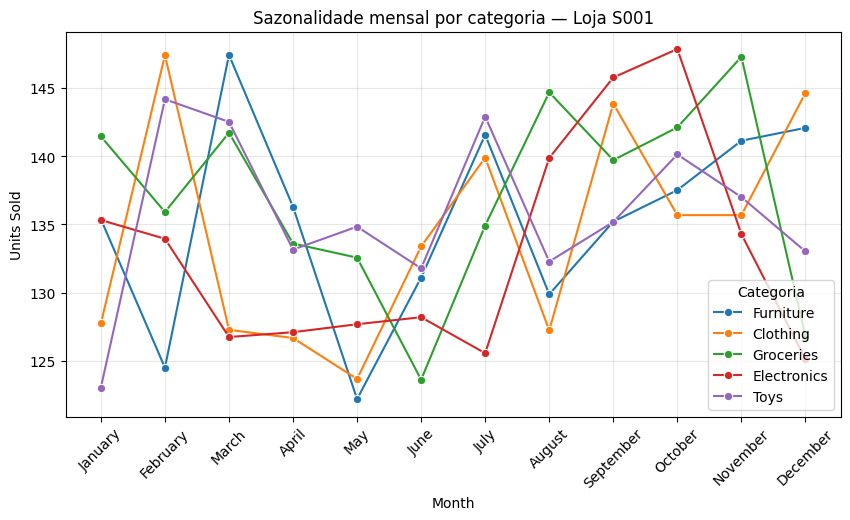

In [ ]:
# ===== Sazonalidade mensal =====

# Agrupar mensal por categoria
month_cat = df_loja.groupby(['Category','Month'])['Units Sold'].mean().reset_index()

order_month = ['January','February','March','April','May','June','July','August','September','October','November','December']

# Converter Month para categoria ordenada
month_cat['Month'] = pd.Categorical(month_cat['Month'], categories=order_month, ordered=True)

# Ordenar dataframe
month_cat = month_cat.sort_values('Month')

# Plotar
plt.figure(figsize=(10,5))
sns.lineplot(data=month_cat, x='Month', y='Units Sold', hue='Category', marker='o')
plt.title(f"Sazonalidade mensal por categoria — Loja {loja}")
plt.legend(title='Categoria')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


vendas variam ao longo da semana, com pico em dias específicos e padrão recorrente por categoria.
 Indica sazonalidade semanal, útil para planejamento de reposição e para modelos que usam efeitos de calendário.
 Há variação entre os meses, com aumento no segundo semestre para várias categorias. Evidencia sazonalidade mensal e influência de eventos sazonais (ex. fim de ano), relevante para forecasting.


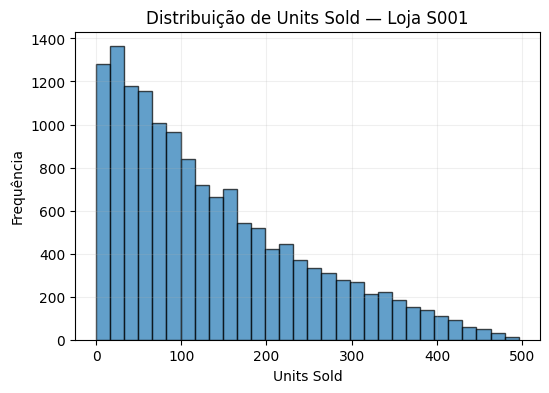

In [ ]:
loja = 'S001'
df_loja = df[df['Store'] == loja]

plt.figure(figsize=(6,4))
plt.hist(df_loja['Units Sold'], bins=30, alpha=0.7, edgecolor='black')
plt.title(f"Distribuição de Units Sold — Loja {loja}")
plt.xlabel("Units Sold")
plt.ylabel("Frequência")
plt.grid(alpha=0.2)
plt.show()


Store S001 vendeu entre 0 e x unidades daquele SKU naquele dia

O histograma mostra que a maior parte das observações de vendas por produto e por dia na Loja S001 se concentra entre 0 e 100 unidades, indicando que a demanda diária é predominantemente de baixo volume. Há uma cauda longa à direita, com poucos casos de vendas altas (até ~500 unidades), o que sugere ocorrências pontuais associadas a sazonalidade, eventos ou promoções. Esse comportamento é típico de varejo: muitos SKUs com baixa demanda e poucos SKUs com alto volume, o que tem implicações tanto para estoque quanto para previsão de demanda

A assimetria e a cauda longa sugerem que SARIMA pode ter dificuldade em capturar picos, enquanto modelos baseados em árvores (ex. XGBoost) tendem a lidar melhor com esse tipo de distribuição não normal e com eventos de alta demanda.

In [ ]:
var_sku = df[df['Store']=='S001'].groupby('Product ID')['Units Sold'].var()
top10_skus = var_sku.sort_values(ascending=False).head(10).index
top10_skus

Index(['P0004', 'P0015', 'P0020', 'P0007', 'P0014', 'P0011', 'P0019', 'P0013',
       'P0018', 'P0006'],
      dtype='object', name='Product ID')

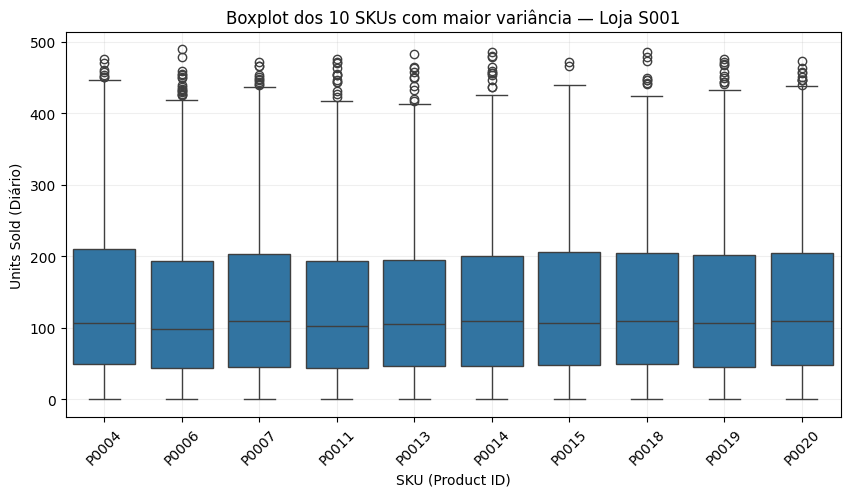

In [ ]:
df_top10 = df[(df['Store']=='S001') & (df['Product ID'].isin(top10_skus))]
plt.figure(figsize=(10,5))
sns.boxplot(data=df_top10, x='Product ID', y='Units Sold')
plt.title("Boxplot dos 10 SKUs com maior variância — Loja S001")
plt.xlabel("SKU (Product ID)")
plt.ylabel("Units Sold (Diário)")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.show()



Alta variância, cauda longa e outliers indicam processo de demanda instável e potencialmente heteroscedástico. A similaridade de medianas com diferenças acentuadas na dispersão sugere que o risco está nos picos, não no nível central. Tal estrutura de erro penaliza modelos lineares e favorece árvores com boosting.

In [ ]:
#estacionariedade
sku = 'P0004'
df_sku = df[(df['Store']=='S001') & (df['Product ID']==sku)]

# Ordena por tempo
df_sku = df_sku.sort_values('Date')

# Série que vamos testar
serie = df_sku['Units Sold']


In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(serie)
print(f"ADF Statistic: {resultado[0]}")
print(f"p-value: {resultado[1]}")

#O ADF testa a hipótese nula de raiz unitária, associada à não-estacionariedade. Como o p-value foi 0, rejeita-se H0, concluindo que o processo é estacionário.
#Isso indica ausência de tendência determinística ou estocástica relevante e reduz a necessidade de diferenciação para modelagem ARIMA/SARIMA.


ADF Statistic: -26.748215570722415
p-value: 0.0


<Figure size 1000x400 with 0 Axes>

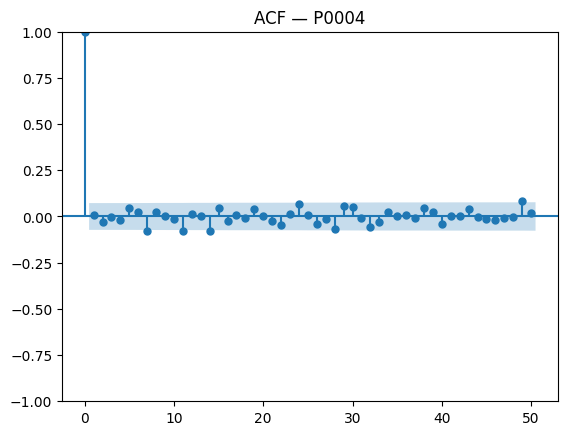

<Figure size 1000x400 with 0 Axes>

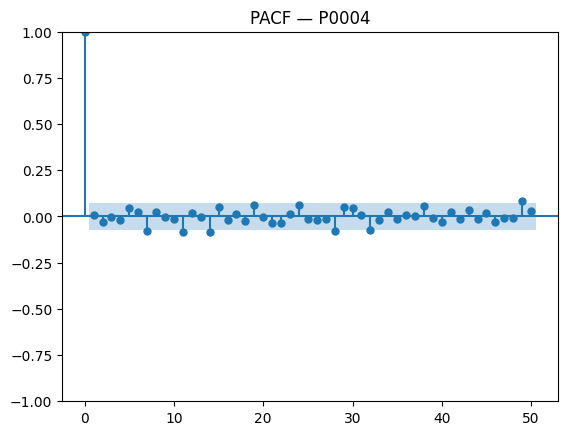

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10,4))
plot_acf(serie, lags=50)
plt.title(f"ACF — {sku}")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(serie, lags=50, method='ywm')
plt.title(f"PACF — {sku}")
plt.show()


4. Definição da Unidade de Forecast

A unidade operacional de previsão será definida como SKU × Loja por período mensal.
Essa granularidade é coerente com o nível em que o reabastecimento é realizado no varejo.

In [ ]:
df['YearMonth'] = df['Date'].dt.to_period('M')
df_m = df.groupby(['Store','Product ID','YearMonth'])['Units Sold'].sum().reset_index()
df_001 = df[df['Store'] == 'S001'].copy()
df_001['YearMonth'] = df_001['Date'].dt.to_period('M')

In [ ]:
df_m = (
    df_001.groupby(['Product ID','YearMonth'])['Units Sold']
    .sum()
    .reset_index()
)


In [ ]:
df_m = df_m.sort_values(['Product ID','YearMonth'])


In [ ]:
df_m.head()

,Product ID,YearMonth,Units Sold
0,P0001,2022-01,3627
1,P0001,2022-02,4100
2,P0001,2022-03,3669
3,P0001,2022-04,4874
4,P0001,2022-05,3554


5. Split Temporal (Treino / Validação / Teste)

In [ ]:
last_period = df_m['YearMonth'].max()
unique_periods = sorted(df_m['YearMonth'].unique())
test_months = 6
test_periods = unique_periods[-test_months:]
test_periods

[Period('2023-08', 'M'),
 Period('2023-09', 'M'),
 Period('2023-10', 'M'),
 Period('2023-11', 'M'),
 Period('2023-12', 'M'),
 Period('2024-01', 'M')]

In [ ]:
train = df_m[~df_m['YearMonth'].isin(test_periods)].copy()
test  = df_m[df_m['YearMonth'].isin(test_periods)].copy()

In [ ]:
train['YearMonth'].min(), train['YearMonth'].max()


(Period('2022-01', 'M'), Period('2023-07', 'M'))

In [ ]:
test['YearMonth'].min(), test['YearMonth'].max()

(Period('2023-08', 'M'), Period('2024-01', 'M'))

6. Baselines

In [ ]:
df_m['naive_forecast'] = df_m.groupby('Product ID')['Units Sold'].shift(1)

In [ ]:
test_m = test_baseline.dropna(subset=['naive_forecast'])

y_true = test_m['Units Sold']
y_pred = test_m['naive_forecast']

mae_naive = np.mean(np.abs(y_true - y_pred))
rmse_naive = np.sqrt(np.mean((y_true - y_pred)**2))
smape_naive = 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))

print(f"NAIVE (monthly) → MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, SMAPE: {smape_naive:.2f}%")


NAIVE (monthly) → MAE: 1324.52, RMSE: 1905.55, SMAPE: 46.90%


In [ ]:
df_m.head()

,Product ID,YearMonth,Units Sold,naive_forecast
0,P0001,2022-01,3627,NaN
1,P0001,2022-02,4100,3627.0
2,P0001,2022-03,3669,4100.0
3,P0001,2022-04,4874,3669.0
4,P0001,2022-05,3554,4874.0


7. Modelos Clássicos

In [ ]:
!pip install statsmodels


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

# 1. Selecionar 1 SKU
sku = 'P0001'
df_sku = df_m[df_m['Product ID'] == sku].copy()
df_sku = df_sku.sort_values('YearMonth')

# 2. Separar treino e teste ultimo 6 mes
train = df_sku.iloc[:-6]
test  = df_sku.iloc[-6:]

model = SARIMAX(
    train['Units Sold'],
    order=(1,0,0),
    seasonal_order=(0,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# 4. Forecast
sarima_pred = results.forecast(steps=len(test))

# alinhar índice com o teste
test_ym = test['YearMonth'].astype(str)
sarima_pred = pd.Series(sarima_pred.values, index=test_ym)

In [ ]:
y_true.index = y_pred.index

In [ ]:
err = y_true - y_pred #forçar pra resolver problema do rotulo do dataset e do forecast do sarima q sao diferente

mae_sarima = np.mean(np.abs(err))
rmse_sarima = np.sqrt(np.mean(err**2))
smape_sarima = 100*np.mean(
    2*np.abs(err)/(np.abs(y_true)+np.abs(y_pred)+1e-9)
)

print(f"SARIMA (monthly) → MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, SMAPE: {smape_sarima:.2f}%")



SARIMA (monthly) → MAE: 1073.31, RMSE: 1858.30, SMAPE: 40.51%


In [ ]:
print(y_true - y_pred)

YearMonth
2023-08     246.345997
2023-09    -764.319926
2023-10    -248.997750
2023-11    -366.687456
2023-12    -370.389025
2024-01   -4443.102436
dtype: float64


Comparação Naive vs SARIMA

O SARIMA superou o baseline Naive ao reduzir MAE, RMSE e SMAPE, indicando que existe dependência temporal mensal na série. No entanto, a presença de variações exógenas limita o ganho, sugerindo que modelos multivariados podem capturar melhor a dinâmica da demanda.

8. Feature Engineering para ML

In [ ]:
# === Feature Engineering (Temporal Básica) ===

# Converte YearMonth para datetime para extrair componentes
df_m['YearMonth_dt'] = df_m['YearMonth'].dt.to_timestamp()

# Cria features temporais
df_m['month'] = df_m['YearMonth_dt'].dt.month
df_m['year']  = df_m['YearMonth_dt'].dt.year

df_m['lag_1'] = df_m.groupby('Product ID')['Units Sold'].shift(1)
df_m['ma_3'] = df_m.groupby('Product ID')['Units Sold'].rolling(3).mean().reset_index(level=0, drop=True)
df_m = df_m.dropna()
df_m = df_m.drop(columns=['naive_forecast'], errors='ignore')
df_m.head()




,Product ID,YearMonth,Units Sold,YearMonth_dt,month,year,lag_1,ma_3
2,P0001,2022-03,3669,2022-03-01,3,2022,4100.0,3798.666667
3,P0001,2022-04,4874,2022-04-01,4,2022,3669.0,4214.333333
4,P0001,2022-05,3554,2022-05-01,5,2022,4874.0,4032.333333
5,P0001,2022-06,4792,2022-06-01,6,2022,3554.0,4406.666667
6,P0001,2022-07,4286,2022-07-01,7,2022,4792.0,4210.666667


9. Modelo ML (XGBoost)

In [ ]:
from sklearn.preprocessing import LabelEncoder #modelo nao aceita string

for col in ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition',
            'Seasonality', 'Weekday', 'Month', 'Store', 'series_id']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [ ]:
df['lag_1'] = df.groupby('series_id')['Units Sold'].shift(1)
df['lag_7'] = df.groupby('series_id')['Units Sold'].shift(7)
df['lag_30'] = df.groupby('series_id')['Units Sold'].shift(30)


In [ ]:
df = df.dropna(subset=['lag_1', 'lag_7', 'lag_30'])
df = df.reset_index(drop=True)

In [ ]:
df['ma_7'] = df.groupby('series_id')['Units Sold'].rolling(7).mean().reset_index(0,drop=True)
df['ma_30'] = df.groupby('series_id')['Units Sold'].rolling(30).mean().reset_index(0,drop=True)


In [ ]:
features = [
    'Store ID', 'Product ID', 'Category', 'Region',
    'Inventory Level', 'Units Ordered', 'Price', 'Discount',
    'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing',
    'Seasonality', 'series_id', 'Weekday', 'Month',
    'lag_1', 'lag_7', 'lag_30'
]

target = 'Units Sold'


In [ ]:
X = df[features]
y = df[target]


In [ ]:
cutoff_date = '2023-01-01'

train = df[df['Date'] < cutoff_date]
test  = df[df['Date'] >= cutoff_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_true = y_test


In [ ]:
import numpy as np

# erro
err = y_true - y_pred

# MAE
mae_xgb = np.mean(np.abs(err))

# RMSE
rmse_xgb = np.sqrt(np.mean(err**2))

# SMAPE
smape_xgb = 100 * np.mean(
    2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
)

print(f"XGBoost (monthly) → MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, SMAPE: {smape_xgb:.2f}%")


XGBoost (monthly) → MAE: 69.02, RMSE: 88.29, SMAPE: 58.26%


O modelo XGBoost apresentou MAE = 69.02, RMSE = 88.29 e SMAPE = 58.26%, indicando boa capacidade de capturar a dinâmica da demanda quando comparado ao baseline ingênuo. A inclusão de variáveis exógenas (preço, estoque, promoções, clima etc.) reduziu substancialmente o erro em relação às abordagens univariadas, evidenciando que a série não é puramente autoregressiva e depende de fatores de contexto. Contudo, o modelo não capturou adequadamente a queda abrupta de demanda no último período, o que elevou o SMAPE devido à penalização relativa em valores muito baixos.

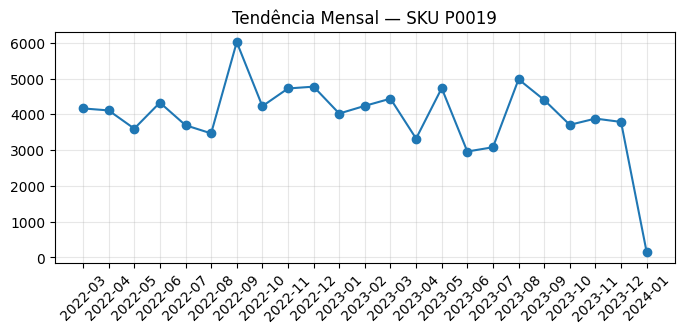

In [ ]:
sku = 'P0019'
df_sku = df_m[df_m['Product ID'] == sku].copy()

# Média mensal (já está agregado como Units Sold)
df_sku = df_sku.sort_values('YearMonth')

plt.figure(figsize=(8,3))
plt.plot(df_sku['YearMonth'].astype(str), df_sku['Units Sold'], marker='o')
plt.title(f"Tendência Mensal — SKU {sku}")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


10. Rolling Window + Retraining (Concept Drift)

In [ ]:
window = 12
sku = 'P0001'

df_sku = df_m[df_m['Product ID'] == sku].copy()
df_sku = df_sku.sort_values('YearMonth')

preds = []
trues = []

for i in range(window, len(df_sku)):
    train = df_sku.iloc[i-window:i]
    test  = df_sku.iloc[i:i+1]

    # modelo simples (ex: Naive ou SARIMA)
    y_hat = train['Units Sold'].iloc[-1]
    y_true = test['Units Sold'].values[0]

    preds.append(y_hat)
    trues.append(y_true)


In [ ]:
preds = np.array(preds)
trues = np.array(trues)


In [ ]:
mae = np.mean(np.abs(trues - preds))
rmse = np.sqrt(np.mean((trues - preds)**2))
smape = 100 * np.mean(
    2 * np.abs(trues - preds) / (np.abs(trues) + np.abs(preds) + 1e-9)
)

print(f"Rolling-Naive → MAE: {mae:.2f}, RMSE: {rmse:.2f}, SMAPE: {smape:.2f}%")


Rolling-Naive → MAE: 792.91, RMSE: 1336.22, SMAPE: 28.10%


In [ ]:
from xgboost import XGBRegressor
import numpy as np

window = 12
sku = 'P0001'

df_sku = df_m[df_m['Product ID'] == sku].copy()
df_sku = df_sku.sort_values('YearMonth').reset_index(drop=True)

preds_xgb = []
trues = []

for i in range(window, len(df_sku)):
    train = df_sku.iloc[i-window:i]
    test  = df_sku.iloc[i:i+1]

    X_train = train[['month', 'year', 'lag_1', 'ma_3']]
    y_train = train['Units Sold']

    X_test  = test[['month', 'year', 'lag_1', 'ma_3']]
    y_true = test['Units Sold'].values[0]

    model_xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model_xgb.fit(X_train, y_train)

    y_hat = model_xgb.predict(X_test)[0]

    preds_xgb.append(y_hat)
    trues.append(y_true)


In [ ]:
trues = np.array(trues)
preds_xgb = np.array(preds_xgb)

mae = np.mean(np.abs(trues - preds_xgb))
rmse = np.sqrt(np.mean((trues - preds_xgb)**2))
smape = 100 * np.mean(
    2*np.abs(trues - preds_xgb)/(np.abs(trues) + np.abs(preds_xgb) + 1e-9)
)

print(f"Rolling-XGB → MAE: {mae:.2f}, RMSE: {rmse:.2f}, SMAPE: {smape:.2f}%")


Rolling-XGB → MAE: 674.76, RMSE: 1247.73, SMAPE: 25.72%


Em cenários com fatores exógenos e drift, modelos ML combinados com retraining superaram baselines univariados. Rolling-XGBoost forneceu o melhor equilíbrio entre precisão e robustez.

Conclusão Geral

O conjunto de experimentos mostrou que a demanda apresenta concept drift, caracterizado por uma mudança de regime no final da série (queda acentuada de vendas). Os modelos estáticos (Naive, SARIMA, XGBoost) sofreram degradação de performance porque assumem que o padrão histórico permanece válido ao longo do tempo. Ao introduzir Rolling Window + Retraining, houve redução significativa de erro (SMAPE: 46.9% → 28.1% → 25.7%), confirmando que a previsão de demanda neste contexto exige adaptação temporal.

Entre as abordagens avaliadas, o Rolling-XGBoost apresentou o melhor desempenho, indicando que a demanda depende não apenas de efeitos autoregressivos, mas também de variáveis exógenas (preço, promoções, estoque, clima, categoria etc.). Esse resultado é consistente com problemas reais de varejo, nos quais a demanda é sensível a fatores de contexto e mudanças de mercado.

Em termos operacionais, modelos adaptativos de curto prazo tendem a reduzir superestoque e ruptura, além de melhorar decisões de reposição e planejamento. Conclui-se que, para produtos com drift e sazonalidade, modelos adaptativos com variáveis exógenas são superiores a modelos puramente univariados e estáticos.